In [1]:
from bauer.models import FlexibleNoiseRiskModel, RegressionModel, FlexibleNoiseRisRegressionkModel

from bauer.utils.data import load_garcia2022

In [2]:
from warnings import warn

In [3]:
df = load_garcia2022(task='risk',).reset_index('format')

In [4]:
model = FlexibleNoiseRisRegressionkModel(df, {'evidence_sd':'format'}, prior_estimate='shared', fit_seperate_evidence_sd=False)

{'evidence_sd_spline1': {'mu_intercept': 5.0, 'sigma_intercept': 5.0, 'transform': 'identity'}, 'evidence_sd_spline2': {'mu_intercept': 5.0, 'sigma_intercept': 5.0, 'transform': 'identity'}, 'evidence_sd_spline3': {'mu_intercept': 5.0, 'sigma_intercept': 5.0, 'transform': 'identity'}, 'evidence_sd_spline4': {'mu_intercept': 5.0, 'sigma_intercept': 5.0, 'transform': 'identity'}, 'evidence_sd_spline5': {'mu_intercept': 5.0, 'sigma_intercept': 5.0, 'transform': 'identity'}, 'prior_mu': {'mu_intercept': 22.731005245620402, 'sigma_intercept': 25.0, 'transform': 'identity'}, 'prior_sd': {'mu_intercept': 22.731005245620402, 'sigma_intercept': 25.0, 'transform': 'softplus'}}


/Users/gdehol/git/bauer/bauer/models.py:1453: UserWarning: Found evidence_sd in regressors, will add it for all 5 splines!
  warn(f'Found {key} in regressors, will add it for all {po} splines!')


In [5]:
model.build_estimation_model()

{'evidence_sd_spline1': {'mu_intercept': 5.0, 'sigma_intercept': 5.0, 'transform': 'identity'}, 'evidence_sd_spline2': {'mu_intercept': 5.0, 'sigma_intercept': 5.0, 'transform': 'identity'}, 'evidence_sd_spline3': {'mu_intercept': 5.0, 'sigma_intercept': 5.0, 'transform': 'identity'}, 'evidence_sd_spline4': {'mu_intercept': 5.0, 'sigma_intercept': 5.0, 'transform': 'identity'}, 'evidence_sd_spline5': {'mu_intercept': 5.0, 'sigma_intercept': 5.0, 'transform': 'identity'}, 'prior_mu': {'mu_intercept': 22.731005245620402, 'sigma_intercept': 25.0, 'transform': 'identity'}, 'prior_sd': {'mu_intercept': 22.731005245620402, 'sigma_intercept': 25.0, 'transform': 'softplus'}}


In [6]:
# idata = model.sample(500, 500)

In [7]:
# idata.to_netcdf('./flexible_noise_regression_model.netcdf')

In [8]:
import arviz as az
idata = az.from_netcdf('./flexible_noise_regression_model.netcdf')

In [9]:
idata.posterior['evidence_sd_spline1_mu'].to_dataframe().head()

evidence_sd_spline1_mu
chain draw evidence_sd_spline1_regressors                        
0     0    Intercept                                     1.806550
           format[T.symbolic]                           -0.191281
      1    Intercept                                     1.844356
           format[T.symbolic]                           -0.169400
      2    Intercept                                     1.652084

In [10]:
import pandas as pd

n_polynomials = 5

intercept_pars = pd.concat([idata.posterior[f'evidence_sd_spline{spline_n}_mu'].to_dataframe().xs('Intercept', level=-1) for spline_n in range(1, n_polynomials+1)], axis=1)
t_symbolic_pars =  pd.concat([idata.posterior[f'evidence_sd_spline{spline_n}_mu'].to_dataframe().xs('format[T.symbolic]', level=-1) for spline_n in range(1, n_polynomials+1)], axis=1)

pars_non_symbolic = intercept_pars
pars_symbolic = intercept_pars + t_symbolic_pars


In [11]:
import numpy as np
x = np.linspace(5, 100)
dm = model.make_dm(x, variable='evidence_sd')

In [12]:

evidence_sd_non_symbolic = pd.DataFrame(dm.dot(pars_non_symbolic.T),
                                        index=pd.Index(x, name='x'),
                                        columns=pars_non_symbolic.index).stack([0, 1]).to_frame('sd')

evidence_sd_symbolic = pd.DataFrame(dm.dot(pars_symbolic.T),
                                        index=pd.Index(x, name='x'),
                                        columns=pars_symbolic.index).stack([0, 1]).to_frame('sd')

evidence_sd = pd.concat([evidence_sd_non_symbolic, evidence_sd_symbolic], keys=['non_symbolic', 'symbolic'],
                        names=['format'], axis=0)

In [13]:
from arviz import hdi

def get_hdi(d):
    return hdi(d.values, hdi_prob=0.95, axis=0)

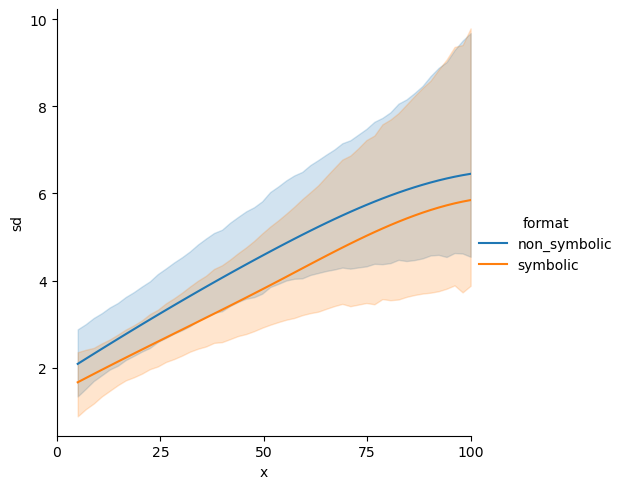

In [14]:
import seaborn as sns
g = sns.relplot(data=evidence_sd.reset_index(), x='x', y='sd', hue='format', kind='line', errorbar=get_hdi)

g.set(xlim=(0, 100), xticks=[0, 25, 50, 75, 100])

In [15]:
ppc = model.ppc(df, idata)

Sampling: [ll_bernoulli]


In [16]:
ppc = ppc.stack([0, 1]).to_frame('p_choice')

In [17]:
ppc

p_choice
variable     subject run trial_nr format       p1  n1 p2   n2 log(risky/safe) choice chain draw          
ll_bernoulli 1       1   1        non-symbolic 1.0 14 0.55 47 1.211090        True   0     0            1
                                                                                           1            1
                                                                                           2            1
                                                                                           3            1
                                                                                           4            1
...                                                                                                   ...
             64      5   240      symbolic     1.0 28 0.55 29 0.035091        False  3     495          0
                                                                                           496          0
                                                                                           497          0
                                                                                           498          0
                                                                                           499          0

[60622000 rows x 1 columns]

In [18]:
ppc.groupby(['chain', 'draw', 'subject', 'n_safe', 'log(risky/safe)']).mean()

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/gdehol/mambaforge/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 3460, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_86333/3845923758.py", line 1, in <module>
    ppc.groupby(['chain', 'draw', 'subject', 'n_safe', 'log(risky/safe)']).mean()
  File "/Users/gdehol/mambaforge/lib/python3.10/site-packages/pandas/core/frame.py", line 8869, in groupby
    return DataFrameGroupBy(
  File "/Users/gdehol/mambaforge/lib/python3.10/site-packages/pandas/core/groupby/groupby.py", line 1278, in __init__
    grouper, exclusions, obj = get_grouper(
  File "/Users/gdehol/mambaforge/lib/python3.10/site-packages/pandas/core/groupby/grouper.py", line 1009, in get_grouper
    raise KeyError(gpr)
KeyError: 'n_safe'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/gdehol/mambaforge/